# 03 - Análisis de resultados y decisión

Acá corremos el test de hipótesis formal sobre el experimento del cartel de
promoción, usando **la unidad correcta de análisis: el día** (día x sucursal),
tal como se planteó en el notebook 01. También mostramos, a modo de contraste
educativo, qué hubiera pasado si (incorrectamente) se analizaran los
visitantes individuales como si fueran observaciones independientes -- y por
qué eso da una falsa sensación de seguridad. Cerramos con una recomendación de
negocio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

metricas = pd.read_csv("../data/processed/metricas_diarias.csv", parse_dates=["fecha"])
df = pd.read_csv("../data/raw/experimento_cartel.csv", parse_dates=["fecha"])
metricas.head()

,fecha,sucursal,variante,dia_semana,semana,visitantes,compras,conversion_dia,ticket_promedio_dia
0,2026-03-02,Centro,B,Lunes,1,157,28,0.178344,43764.923571
1,2026-03-02,Norte,A,Lunes,1,110,23,0.209091,46633.181304
2,2026-03-02,Oeste,B,Lunes,1,129,11,0.085271,37268.610000
3,2026-03-02,Sur,A,Lunes,1,94,12,0.127660,50657.785000
4,2026-03-03,Centro,A,Martes,1,145,25,0.172414,40908.787200


## 1. Test correcto: comparación a nivel día

**Hipótesis:**

- H0 (hipótesis nula): no hay diferencia real en la conversión promedio diaria
  entre la variante A y la B.
- H1 (hipótesis alternativa): sí hay una diferencia.

Usamos un **t-test de dos muestras independientes** sobre la conversión diaria
(una observación por día x sucursal) y otro sobre el ticket promedio diario.
Fijamos alpha = 0.05 de antemano (como se discutió en el notebook 02).

In [2]:
conv_A = metricas.loc[metricas["variante"] == "A", "conversion_dia"]
conv_B = metricas.loc[metricas["variante"] == "B", "conversion_dia"]

t_stat_conv, p_valor_conv = stats.ttest_ind(conv_B, conv_A, equal_var=False)

diferencia_conv = conv_B.mean() - conv_A.mean()
se_diferencia_conv = np.sqrt(conv_A.var(ddof=1) / len(conv_A) + conv_B.var(ddof=1) / len(conv_B))
ic_95_conv = (diferencia_conv - 1.96 * se_diferencia_conv, diferencia_conv + 1.96 * se_diferencia_conv)

print("=== Conversión diaria: B vs. A ===")
print(f"Media A: {conv_A.mean():.4f} | Media B: {conv_B.mean():.4f}")
print(f"Diferencia (B - A): {diferencia_conv:+.4f} ({diferencia_conv*100:+.2f} puntos porcentuales)")
print(f"IC 95% de la diferencia: [{ic_95_conv[0]*100:+.2f}, {ic_95_conv[1]*100:+.2f}] puntos porcentuales")
print(f"Estadístico t: {t_stat_conv:.3f} | p-valor: {p_valor_conv:.2e}")
print(f"¿Diferencia estadísticamente significativa (alpha=0.05)? {'Sí' if p_valor_conv < 0.05 else 'No'}")

=== Conversión diaria: B vs. A ===
Media A: 0.1830 | Media B: 0.2243
Diferencia (B - A): +0.0413 (+4.13 puntos porcentuales)
IC 95% de la diferencia: [+2.74, +5.52] puntos porcentuales
Estadístico t: 5.822 | p-valor: 1.88e-08
¿Diferencia estadísticamente significativa (alpha=0.05)? Sí


In [3]:
ticket_A = metricas.loc[metricas["variante"] == "A", "ticket_promedio_dia"].dropna()
ticket_B = metricas.loc[metricas["variante"] == "B", "ticket_promedio_dia"].dropna()

t_stat_ticket, p_valor_ticket = stats.ttest_ind(ticket_B, ticket_A, equal_var=False)

diferencia_ticket = ticket_B.mean() - ticket_A.mean()
se_diferencia_ticket = np.sqrt(ticket_A.var(ddof=1) / len(ticket_A) + ticket_B.var(ddof=1) / len(ticket_B))
ic_95_ticket = (diferencia_ticket - 1.96 * se_diferencia_ticket, diferencia_ticket + 1.96 * se_diferencia_ticket)

print("=== Ticket promedio diario: B vs. A ===")
print(f"Media A: ${ticket_A.mean():,.0f} | Media B: ${ticket_B.mean():,.0f}")
print(f"Diferencia (B - A): ${diferencia_ticket:+,.0f} ({diferencia_ticket/ticket_A.mean()*100:+.1f}% relativo)")
print(f"IC 95% de la diferencia: [${ic_95_ticket[0]:+,.0f}, ${ic_95_ticket[1]:+,.0f}]")
print(f"Estadístico t: {t_stat_ticket:.3f} | p-valor: {p_valor_ticket:.2e}")
print(f"¿Diferencia estadísticamente significativa (alpha=0.05)? {'Sí' if p_valor_ticket < 0.05 else 'No'}")

=== Ticket promedio diario: B vs. A ===
Media A: $44,553 | Media B: $48,438
Diferencia (B - A): $+3,885 (+8.7% relativo)
IC 95% de la diferencia: [$+2,372, $+5,398]
Estadístico t: 5.033 | p-valor: 9.67e-07
¿Diferencia estadísticamente significativa (alpha=0.05)? Sí


**Resultado del test correcto (nivel día):**

- **Conversión:** B − A = **+4,13 pp** (IC 95% [+2,74; +5,52]), t = 5,82,
  **p = 1,9e-08**. Significativa y con IC que no incluye el cero.
- **Ticket promedio:** B − A = **+$3.885 (+8,7%)**, p = 9,7e-07, IC también por
  encima de cero.

Ambos efectos recuperan casi exactamente lo inyectado en el dataset (+4 pp de
conversión y +8% de ticket) -- la mejor señal de que el análisis está bien
planteado.

*(Nota: el IC usa la aproximación normal (1,96). Con ~120 observaciones por
grupo el valor t de Student es ~1,98, así que la diferencia es despreciable; en
muestras chicas convendría usar `stats.t` directamente.)*

## 2. Contraste: qué pasaría con el enfoque ingenuo (nivel visitante)

Solo a modo de comparación educativa -- **este NO es el análisis
correcto para este experimento**, por las razones que ya discutimos en los
notebooks 01 y 02 (los visitantes del mismo día no son independientes entre
sí). Lo calculamos igual para ver qué tan distinta -- y engañosamente más
"segura" -- se ve la conclusión si se ignora ese problema.

In [4]:
compras_A = df.loc[df["variante"] == "A", "compro"].sum()
n_A = df.loc[df["variante"] == "A", "compro"].shape[0]
compras_B = df.loc[df["variante"] == "B", "compro"].sum()
n_B = df.loc[df["variante"] == "B", "compro"].shape[0]

z_stat, p_valor_ingenuo = proportions_ztest([compras_B, compras_A], [n_B, n_A])

print("=== Enfoque ingenuo: test de proporciones a nivel visitante ===")
print(f"Conversión A: {compras_A/n_A:.4f} (n={n_A:,}) | Conversión B: {compras_B/n_B:.4f} (n={n_B:,})")
print(f"Estadístico z: {z_stat:.3f} | p-valor: {p_valor_ingenuo:.2e}")
print()
print(f"Comparación de p-valores:")
print(f"  Enfoque correcto (nivel día):      p = {p_valor_conv:.2e}")
print(f"  Enfoque ingenuo (nivel visitante): p = {p_valor_ingenuo:.2e}")

=== Enfoque ingenuo: test de proporciones a nivel visitante ===
Conversión A: 0.1797 (n=12,711) | Conversión B: 0.2209 (n=12,762)
Estadístico z: 8.215 | p-valor: 2.12e-16

Comparación de p-valores:
  Enfoque correcto (nivel día):      p = 1.88e-08
  Enfoque ingenuo (nivel visitante): p = 2.12e-16


**El enfoque ingenuo infla la confianza:** a nivel visitante el p-valor da
**2,1e-16**, órdenes de magnitud más chico que el del análisis correcto
(1,9e-08). Eso es pseudoreplicación: al tratar a miles de visitantes
correlacionados dentro del mismo día como independientes, el test "cree" tener
mucha más información de la que hay y se muestra artificialmente más seguro. El
resultado ingenuo **no es válido** para este diseño, aunque el p-valor luzca más
convincente.

## 3. Visualización de las diferencias con su intervalo de confianza

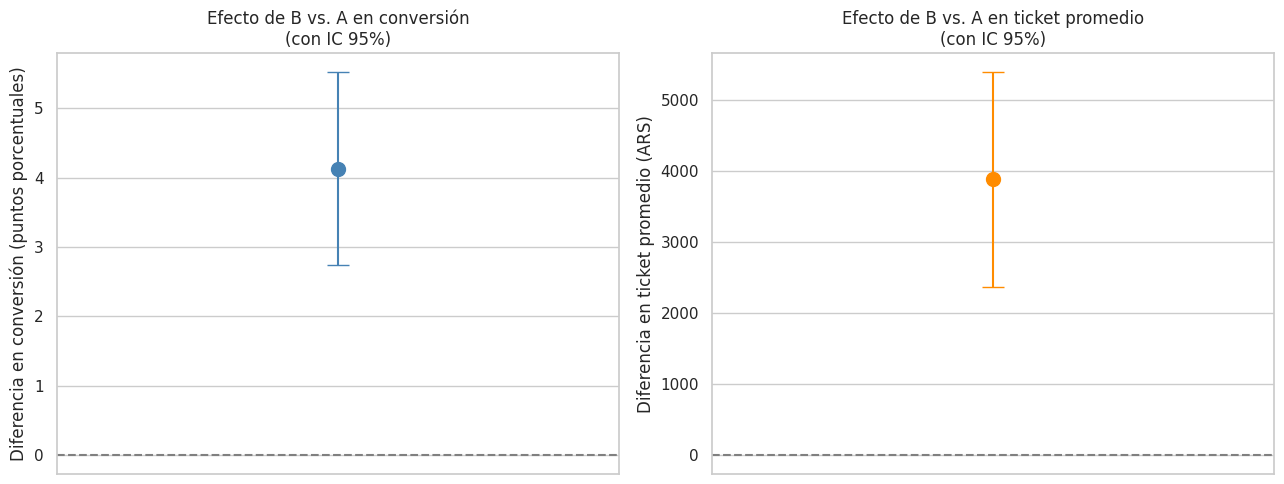

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(
    [0], [diferencia_conv * 100],
    yerr=[[diferencia_conv * 100 - ic_95_conv[0] * 100], [ic_95_conv[1] * 100 - diferencia_conv * 100]],
    fmt="o", markersize=10, capsize=8, color="steelblue",
)
axes[0].axhline(0, color="gray", linestyle="--")
axes[0].set_xticks([])
axes[0].set_ylabel("Diferencia en conversión (puntos porcentuales)")
axes[0].set_title("Efecto de B vs. A en conversión\n(con IC 95%)")

axes[1].errorbar(
    [0], [diferencia_ticket],
    yerr=[[diferencia_ticket - ic_95_ticket[0]], [ic_95_ticket[1] - diferencia_ticket]],
    fmt="o", markersize=10, capsize=8, color="darkorange",
)
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_xticks([])
axes[1].set_ylabel("Diferencia en ticket promedio (ARS)")
axes[1].set_title("Efecto de B vs. A en ticket promedio\n(con IC 95%)")

plt.tight_layout()
plt.show()

## 4. ¿El efecto es consistente entre sucursales?

Una diferencia significativa en el agregado es una buena señal, pero
vale la pena chequear si el efecto se ve parecido en las 4 sucursales, o si
está siendo empujado principalmente por una sola -- eso cambiaría la confianza
en generalizar la conclusión a toda la cadena.

In [6]:
efecto_por_sucursal = metricas.groupby(["sucursal", "variante"])["conversion_dia"].mean().unstack()
efecto_por_sucursal["diferencia_pp"] = (efecto_por_sucursal["B"] - efecto_por_sucursal["A"]) * 100
efecto_por_sucursal.round(4)

variante,A,B,diferencia_pp
sucursal,,,
Centro,0.1579,0.2128,5.4891
Norte,0.1904,0.2398,4.9410
Oeste,0.1668,0.1952,2.8468
Sur,0.2170,0.2495,3.2483


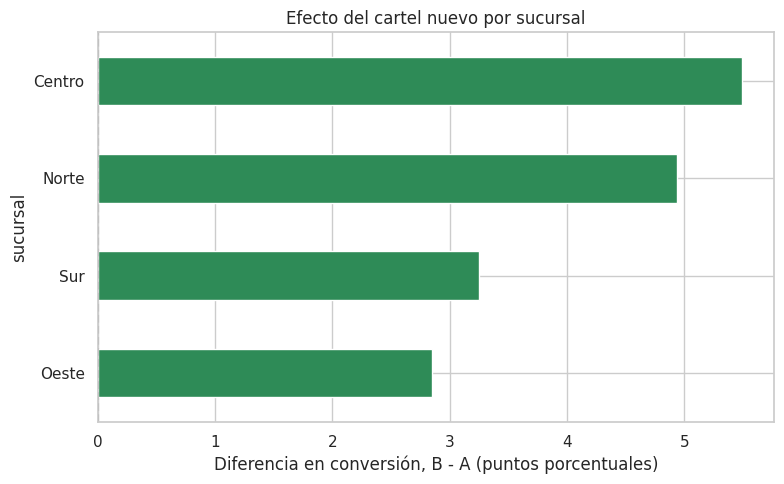

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
efecto_por_sucursal["diferencia_pp"].sort_values().plot(kind="barh", ax=ax, color="seagreen")
ax.axvline(0, color="gray", linestyle="--")
ax.set_xlabel("Diferencia en conversión, B - A (puntos porcentuales)")
ax.set_title("Efecto del cartel nuevo por sucursal")
plt.tight_layout()
plt.show()

**Consistencia entre sucursales:** las 4 muestran el efecto en la misma
dirección: Centro +5,5 pp, Norte +4,9 pp, Sur +3,2 pp y Oeste +2,8 pp. Ninguna
lo contradice ni está "empujando" sola el resultado agregado, lo que da más
confianza para generalizar la recomendación a toda la cadena.

## 5. Significancia estadística vs. significancia práctica (de negocio)

Un resultado puede ser estadísticamente significativo (poco probable que
sea puro azar) y aun así ser demasiado chico como para importarle al negocio.
Acá traducimos el efecto medido a un impacto de negocio estimado, para poder
decidir con esa información -- no solo con el p-valor.

In [8]:
visitantes_totales_categoria_anual = df.groupby("sucursal").size().sum() / (60 / 365)  # extrapolación simple a un año
incremento_compradores_anual = visitantes_totales_categoria_anual * diferencia_conv
ingreso_incremental_por_conversion = incremento_compradores_anual * ticket_A.mean()

ingreso_incremental_por_ticket = (
    df.loc[df["compro"]].groupby("sucursal").size().sum() / (60 / 365)
) * diferencia_ticket

print(f"Visitantes estimados a la categoría por año (extrapolando el tráfico del experimento): {visitantes_totales_categoria_anual:,.0f}")
print(f"Compradores adicionales estimados por año (por el efecto en conversión): {incremento_compradores_anual:,.0f}")
print(f"Ingreso incremental estimado por año (solo por más conversión): ${ingreso_incremental_por_conversion:,.0f}")
print(f"Ingreso incremental estimado por año (solo por mayor ticket promedio): ${ingreso_incremental_por_ticket:,.0f}")
print(f"Ingreso incremental total estimado por año: ${ingreso_incremental_por_conversion + ingreso_incremental_por_ticket:,.0f}")

Visitantes estimados a la categoría por año (extrapolando el tráfico del experimento): 154,961
Compradores adicionales estimados por año (por el efecto en conversión): 6,402
Ingreso incremental estimado por año (solo por más conversión): $285,223,831
Ingreso incremental estimado por año (solo por mayor ticket promedio): $120,596,014
Ingreso incremental total estimado por año: $405,819,845


**Aclaración importante:** esta extrapolación es una simplificación
(asume que el efecto medido durante 10 semanas se mantiene igual todo el año,
sin estacionalidad ni efecto de "novedad" del cartel que se desvanece con el
tiempo) -- se muestra para ilustrar cómo se conecta un resultado estadístico
con una decisión de negocio, no como una proyección financiera precisa.

## 6. Recomendación final

In [9]:
print("=== Resumen del experimento ===")
print(f"Conversión: {diferencia_conv*100:+.2f} puntos porcentuales (p={p_valor_conv:.4f})")
print(f"Ticket promedio: {diferencia_ticket/ticket_A.mean()*100:+.1f}% relativo (p={p_valor_ticket:.4f})")
print(f"Efecto consistente en las {len(efecto_por_sucursal)} sucursales: {(efecto_por_sucursal['diferencia_pp'] > 0).all()}")
print()

if p_valor_conv < 0.05 and p_valor_ticket < 0.05:
    print("Recomendación: implementar el cartel nuevo (variante B) en todas las sucursales.")
    print("Ambas métricas muestran una mejora estadísticamente significativa y de magnitud")
    print("relevante para el negocio, con efecto consistente entre sucursales.")
else:
    print("Recomendación: no hay evidencia suficiente para justificar el cambio todavía.")
    print("Convendría extender el experimento o revisar el diseño antes de decidir.")

=== Resumen del experimento ===
Conversión: +4.13 puntos porcentuales (p=0.0000)
Ticket promedio: +8.7% relativo (p=0.0000)
Efecto consistente en las 4 sucursales: True

Recomendación: implementar el cartel nuevo (variante B) en todas las sucursales.
Ambas métricas muestran una mejora estadísticamente significativa y de magnitud
relevante para el negocio, con efecto consistente entre sucursales.


## Conclusiones

- El análisis correcto (a nivel día) encuentra una diferencia significativa en
  conversión (+4,13 pp, p=1,9e-08) y en ticket (+8,7%, p=9,7e-07), con IC que no
  incluyen el cero.
- El enfoque ingenuo (a nivel visitante) hubiera dado una falsa sensación de
  seguridad (p=2,1e-16) -- confirmación de que la unidad de análisis importa
  tanto como el test.
- El efecto es consistente en las 4 sucursales.
- **Recomendación:** adoptar el cartel nuevo (variante B). El paso siguiente es
  traducir el +4,13 pp y el +8,7% a ingreso incremental proyectado para
  dimensionar el impacto.

**Cierre del proyecto.** La demo de Streamlit explora estos resultados e incluye
una calculadora de tamaño de muestra para futuros experimentos.